In [24]:
import os
import pandas as pd
import numpy as np 
import torch as th
import scipy.stats as stats 
from sklearn import metrics
from matplotlib import pyplot as plt
from model import QComp
from data_tools import QsarDataset


device = th.device("cuda" if th.cuda.is_available() else "cpu")
dtype = th.float32

In [25]:

idx = 0
folder_name = "Mar31_16-37-57_lr0.001"

In [26]:
################################################# SETTING ##################################################
remove_high_corr_col = False


method_name = "QComp"
normalize = True
n_threshold = 5

In [27]:
################################################# METRICS ##################################################

def pearsonr2_function(y_true, y_pred):
    return stats.pearsonr(y_true, y_pred)[0] ** 2

metrics_list = [metrics.root_mean_squared_error,
               metrics.mean_squared_error,
               metrics.mean_absolute_error,
               pearsonr2_function,
               metrics.r2_score]

metrics_name_list = ['rmse', 'mse', 'mae', 'pearsonr2', 'r2_score']

In [28]:
################################################### READ DATA ###################################################
fold_name = "fold_" + str(idx)


#################### data path ####################
dataset_name = "public_data_results"
dataset_path = './{}/random_split_data_results/{}'.format(dataset_name, fold_name)

##### exp data #####
exp_trainset = pd.read_csv(os.path.join(dataset_path, 'public_admet_data_random_{}_train_set.csv'.format(fold_name)))
exp_testset = pd.read_csv(os.path.join(dataset_path, 'public_admet_data_random_{}_test_set.csv'.format(fold_name)))
exp_trainset = exp_trainset.drop(columns=["smiles"])
exp_testset = exp_testset.drop(columns=["smiles"])

##### qsar data #####
qsar_trainset = pd.read_csv(os.path.join(dataset_path, 'chemprop_multitask_pred/public_admet_data_random_{}_train_set_model_pred.csv'.format(fold_name)))
qsar_trainset = qsar_trainset[exp_trainset.columns]
qsar_testset = pd.read_csv(os.path.join(dataset_path, 'chemprop_multitask_pred/public_admet_data_random_{}_test_set_model_pred.csv'.format(fold_name)))
qsar_testset = qsar_testset[exp_testset.columns]


##### tasks #####
tasks = np.array(exp_trainset.columns)
feature_size = exp_trainset.shape[1]

##### to numpy #####
exp_trainset = exp_trainset.to_numpy()
exp_testset = exp_testset.to_numpy()
qsar_trainset = qsar_trainset.to_numpy()
qsar_testset = qsar_testset.to_numpy()

In [29]:
################################################### DATA LOADER ###################################################

dataset = QsarDataset(exp_trainset, qsar_trainset, exp_testset, qsar_testset, assay_names=tasks)

trainset = dataset.get_torch_dataset('train', normalize=normalize)
testset = dataset.get_torch_dataset('test', normalize=normalize)

exp_trainset = trainset.exp_data
qsar_trainset = trainset.qsar_data

exp_testset = testset.exp_data
qsar_testset = testset.qsar_data

In [30]:
################################################### SHORT NAME MAPPING ###################################################

mapping_df = pd.read_csv("public_data_results/all_data/data_count_name_unit_info.csv")
assert list(mapping_df["property"].to_numpy()[:-1]) == list(tasks)
feature_short_name_list = mapping_df["short name"][:-1]

In [31]:
################################################### RESULTS CONTAINER ###################################################

method_list = ["_list", "_qsar_list"]

df_results = pd.DataFrame(index=feature_short_name_list, 
                          columns=[name + method for name in metrics_name_list for method in method_list ])

df_results.reset_index(level=0, inplace=True)
df_results.rename(columns={'short_name':'feature_short_name_list'}, inplace=True)
df_results.head()

,short name,rmse_list,rmse_qsar_list,mse_list,mse_qsar_list,mae_list,mae_qsar_list,pearsonr2_list,pearsonr2_qsar_list,r2_score_list,r2_score_qsar_list
0,"CL microsome, human",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"CL microsome, mouse",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"CL microsome, rat",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"CL total, dog",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"CL total, human",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
################################################### LOAD MODEL ###################################################

checkpoint = th.load("{}/random_split_data_results/{}/runs/{}/model.pth".format(dataset_name, fold_name, folder_name))


if method_name == 'QComp':
    qcomp = QComp(size=feature_size).to(dtype=dtype, device=device)
    qcomp.load_state_dict(checkpoint)
elif method_name == 'MICE' or method_name == 'Missforest':
    imputer = checkpoint

/var/folders/c0/y61z8gzd6353rb1vm_j40fmm0000gn/T/ipykernel_30884/315134327.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = th.load("{}/random_split_data_res

In [33]:
################################################### EVALUATION ###################################################

for target_index in range(feature_size):

    target_feature = tasks[target_index]
    print("-----------", target_index, target_feature)

    ## get the subset where the target is not nan in exp data, as validation set
    filter_notna = ~th.isnan(exp_testset[:,target_index])
    exp_testset_sub = exp_testset[filter_notna]
    qsar_testset_sub = qsar_testset[filter_notna]

    print("Validation set size", exp_testset_sub.shape)

    ## if the validation set is smaller than the threshold, then leave it as nan
    if exp_testset_sub.shape[0] >= n_threshold:

        val_exp_data_masked = exp_testset_sub.clone().detach()
        val_qsar_data = qsar_testset_sub.clone().detach()

        ## mask out all the in vivo assays and the target assay for imputation
        # if remove_high_corr_col:
            # for idx in assay_masked_id_list[target_index]:
                # val_exp_data_masked[:, idx] = th.nan
        val_exp_data_masked[:, target_index] = th.nan

        ## impute the dataset
        if method_name == 'QComp':
            imputed_dataset = []
            for (exp_data_masked, qsar_data_original) in zip(val_exp_data_masked, val_qsar_data):
                imputed_data = qcomp.impute(exp_data_masked, qsar_data_original)
                imputed_dataset.append(imputed_data)
            imputed_dataset = th.stack(imputed_dataset)
        elif method_name == 'MICE' or method_name == 'Missforest':
            ## for MICE and Missforest, we need to concatenate the exp and qsar data for imputation
            testset_exp_qsar = np.concatenate([val_exp_data_masked, val_qsar_data], axis=1)
            imputed_dataset = imputer.transform(testset_exp_qsar)
            imputed_dataset = th.tensor(imputed_dataset, dtype=dtype, device=device)

        ## get the target column for the three datasets
        exp_target = exp_testset_sub[:, target_index]
        imputed_target = imputed_dataset[:, target_index]
        qsar_target = qsar_testset_sub[:, target_index]

        imputed_target = imputed_target.detach() 
        
        for idx, metric in enumerate(metrics_list):
            df_results.loc[target_index, metrics_name_list[idx] + '_list'] = metric(exp_target, imputed_target)
            df_results.loc[target_index, metrics_name_list[idx] + '_qsar_list'] = metric(exp_target, qsar_target)

################################################### SAVE METRICS ###################################################

if not os.path.exists("fig/{}/{}/{}".format(dataset_name, fold_name, folder_name)):
    os.makedirs("fig/{}/{}/{}".format(dataset_name, fold_name, folder_name))

if remove_high_corr_col:
    df_results.to_csv("fig/{}/{}/{}/metrics_remove_high_corr_col.csv".format(dataset_name, fold_name, folder_name), index=False)
else:
    df_results.to_csv("fig/{}/{}/{}/metrics.csv".format(dataset_name, fold_name, folder_name), index=False)

----------- 0 CL_microsome_human
Validation set size torch.Size([1119, 25])
----------- 1 CL_microsome_mouse
Validation set size torch.Size([128, 25])
----------- 2 CL_microsome_rat
Validation set size torch.Size([361, 25])
----------- 3 CL_total_dog
Validation set size torch.Size([64, 25])
----------- 4 CL_total_human
Validation set size torch.Size([160, 25])
----------- 5 CL_total_monkey
Validation set size torch.Size([22, 25])
----------- 6 CL_total_rat
Validation set size torch.Size([82, 25])
----------- 7 CYP2C8_inhibition
Validation set size torch.Size([66, 25])
----------- 8 CYP2C9_inhibition
Validation set size torch.Size([469, 25])
----------- 9 CYP2D6_inhibition
Validation set size torch.Size([481, 25])
----------- 10 CYP3A4_inhibition
Validation set size torch.Size([847, 25])
----------- 11 Dog_fraction_unbound_plasma
Validation set size torch.Size([40, 25])
----------- 12 Human_fraction_unbound_plasma
Validation set size torch.Size([571, 25])
----------- 13 Monkey_fraction_

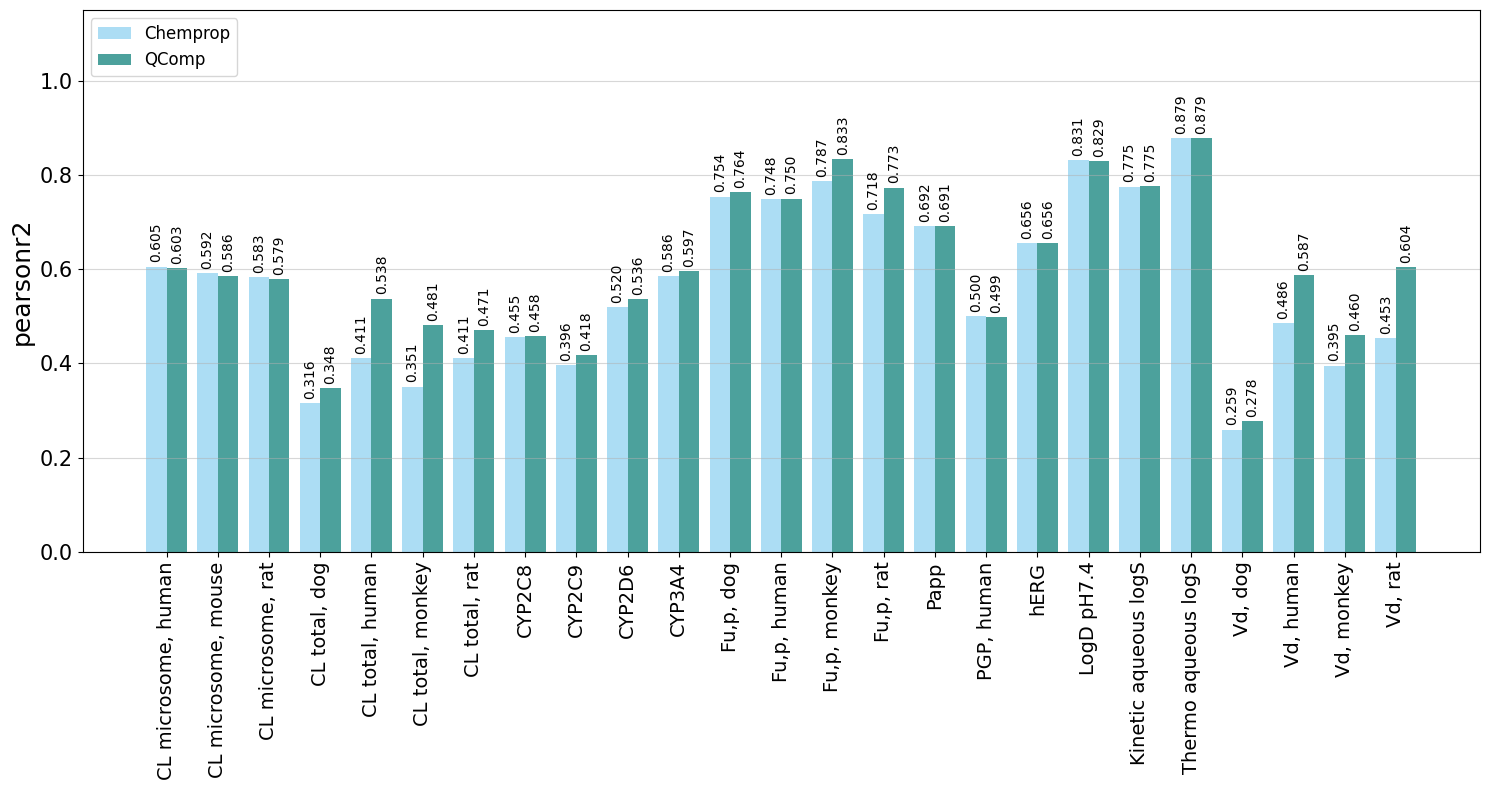

In [34]:
metrics_name = "pearsonr2"

################################################### PLOT ###################################################

bar_width = 0.4

figure, ax = plt.subplots(1, 1, figsize=(15, 8))

x = np.arange(len(feature_short_name_list))
ax.bar(x - bar_width/2, df_results[metrics_name+"_qsar_list"], width=bar_width, alpha=0.7, label="Chemprop", color="#89CFF0")
ax.bar(x + bar_width/2, df_results[metrics_name+"_list"], width=bar_width, alpha=0.7, label=method_name, color="#007a73")
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', label_type='edge', fontsize=10, rotation=90, padding=3)

ax.set_xticks(x)
ax.set_xticklabels(feature_short_name_list, rotation=90, fontsize=14)

ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel(metrics_name, fontsize=18)

ax.set_ylim(0, 1.15)

# ax.set_title(r"Pearson $r^2$", fontsize=18)
ax.grid(axis="y", alpha=0.5)
ax.legend(fontsize=12, loc="upper left")

plt.tight_layout()

if remove_high_corr_col:
    figure.savefig("fig/{}/{}/{}/{}_remove_high_corr_col.png".format(dataset_name, fold_name, folder_name, metrics_name), dpi=300)
else:
    figure.savefig("fig/{}/{}/{}/{}.png".format(dataset_name, fold_name, folder_name, metrics_name), dpi=300)
